# Greedy String Art

Preprocess a target image, precalc the line matrix, then greedily select lines to approximate it.

In [2]:
import matrix
import greedy
from preprocess import circle_crop
from PIL import Image
from importlib import reload
import matplotlib.pyplot as plt
import numpy as np

reload(matrix)
reload(greedy)

<module 'greedy' from '/Users/jackstanley/Documents/VSCode/VSCode_old/string_draw/greedy.py'>

## Settings

Edit image path, resolution, peg count, and line budget here.

In [ ]:
H = 256
P = 120
LINE_WIDTH = 0.08
MAX_LINES = 6000
CIRCLE_PADDING = 32
IMAGE_PATH = 'tiger2.jpg'

## Preprocess target

Crop to a circle on a white background and convert to grayscale.

(256, 256)


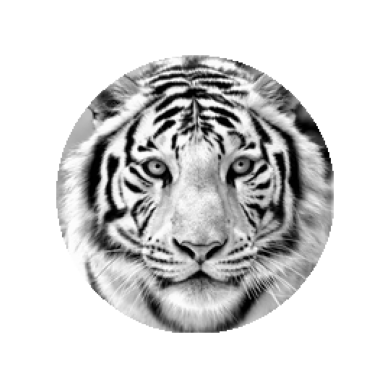

In [14]:
target = Image.open(IMAGE_PATH)
target = circle_crop(target, H, CIRCLE_PADDING).convert('L')
print(np.array(target).shape)

plt.imshow(target, cmap='gray')
plt.axis('off')
plt.show()

## Precalc line matrix

Build the antialiased darkness matrix `M` (one column per peg-to-peg line).

In [15]:
M = matrix.precalc(H, P, line_width=LINE_WIDTH, sparse=False)
print('M shape:', M.shape)

initializing matrix of size 4234936320


100%|██████████| 360/360 [00:04<00:00, 75.06it/s] 


M shape: (65536, 64620)


## Greedy solve

Select lines one at a time (binary 0/1) to minimize MSE against the target. Runs until `MAX_LINES` or all lines are used — lines after the error plateau may worsen the fit, but order is saved so you can render any prefix.

In [16]:
INDICES_PATH = 'greedy_indices.npy'

x, selected = greedy.greedy_solve(
    M,
    np.array(target),
    H,
    max_lines=MAX_LINES,
    line_width=LINE_WIDTH,
    verbose=True,
    save_indices_path=INDICES_PATH,
)

print(f'Selected {len(selected)} lines (saved to {INDICES_PATH})')

KeyboardInterrupt: 

## Render result

Compare the target with reconstructions using the first N lines from the saved order.

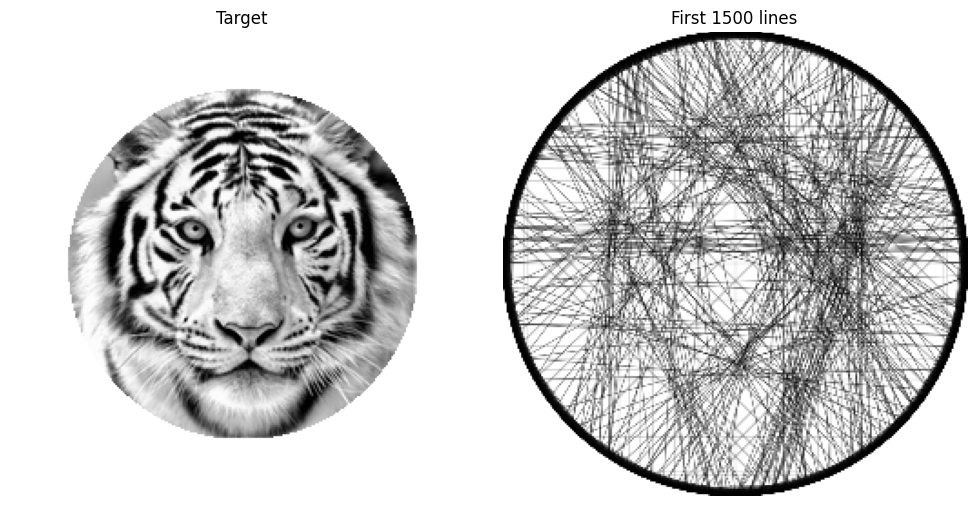

In [12]:
RENDER_N = 1500  # change to preview any prefix of the selection

result = greedy.render_selected(M, selected, H, n=RENDER_N, line_width=LINE_WIDTH)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(target, cmap='gray')
axes[0].set_title('Target')
axes[0].axis('off')

axes[1].imshow(result, cmap='gray')
axes[1].set_title(f'First {min(RENDER_N, len(selected))} lines')
axes[1].axis('off')

plt.tight_layout()
plt.show()